# Dimensionality reduction

This notebook will take you through the different dimensionality reduction data techniques which we went through in the Lecture.

First, lets load/install the packages that we need:

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

We need to define the file which contains the features that you should have collected from the last Lecture. If you didn't manage to get this working properly, the file which I collected earlier. It doesn't matter what your file is called, as long as you specify it between the quotation marks below:

In [2]:
# features_file = ""
features_file = "./AQME_outputs/AQME-ROBERT_interpret_acid_anions_canonical.csv"

Next we need to put these features into a pandas Dataframe - which is essentially a Excel spreadsheet in Python.

In [3]:
df = pd.read_csv(features_file, index_col=0)
df.head()

,SMILES,HOMO-LUMO gap,HOMO,LUMO,IP,EA,Dipole module,Total charge,Global SASA,G solv. in H2O,...,Total FOD,Hardness,Softness,Electronegativity,Electrophil. idx,Nucleophilicity idx,Second IP,Second EA,S0-T1 gap,MolLogP
code_name,,,,,,,,,,,,,,,,,,,,,
Anion_0001,CC(=O)[O-],5.3351,-4.2024,1.1327,3.3045,-10.4249,7.1380,-1.0,192.5967,-68.9658,...,0.0101,13.7294,0.0728,-3.5602,0.4616,4166.6667,11.1108,-9.5398,134.2428,-1.2438
Anion_0002,CCCCCCCC/C=C\CCCCCCCC(=O)O,4.0571,-10.3812,-6.3242,7.6317,-1.4498,1.8413,0.0,600.8035,-9.6848,...,0.0474,9.0814,0.1101,3.0910,0.5261,1.5797,10.8525,3.3430,116.2336,6.1085
Anion_0003,CCCCCCCCCCCCCCCC(=O)[O-],5.3131,-4.3573,0.9559,3.1335,-8.6616,37.5426,-1.0,598.9517,-70.5050,...,0.0103,11.7951,0.0848,-2.7640,0.3239,1843.3891,7.9764,-2.6041,133.7626,4.2176
Anion_0004,CCCCCCCCCCCCCCCCCC(=O)[O-],5.2403,-4.5644,0.6759,3.2112,-8.7797,27.8235,-1.0,610.9026,-69.4885,...,0.0111,11.9909,0.0835,-2.7843,0.3234,1522.5735,7.7882,-3.1213,131.6716,4.9978
Anion_0005,CCCCC/C=C\C/C=C\CCCCCCC(=O)O,4.0262,-10.3534,-6.3272,7.6388,-1.1555,1.8364,0.0,568.8514,-10.4796,...,0.0565,8.7943,0.1137,3.2416,0.5978,1.4856,11.0191,4.1694,111.1059,5.4944


Before getting to the dimensionality reduction part, it's usually a good idea to remove features which are collinear with each other (this prevents two or more columns all providing the same or similar chemical information to the chemical space).

In [20]:
# Remove non-numeric columns (like SMILES)
df_numeric = df.select_dtypes(include=[np.number])

# Remove rows with NaN values
df_numeric = df_numeric.dropna()

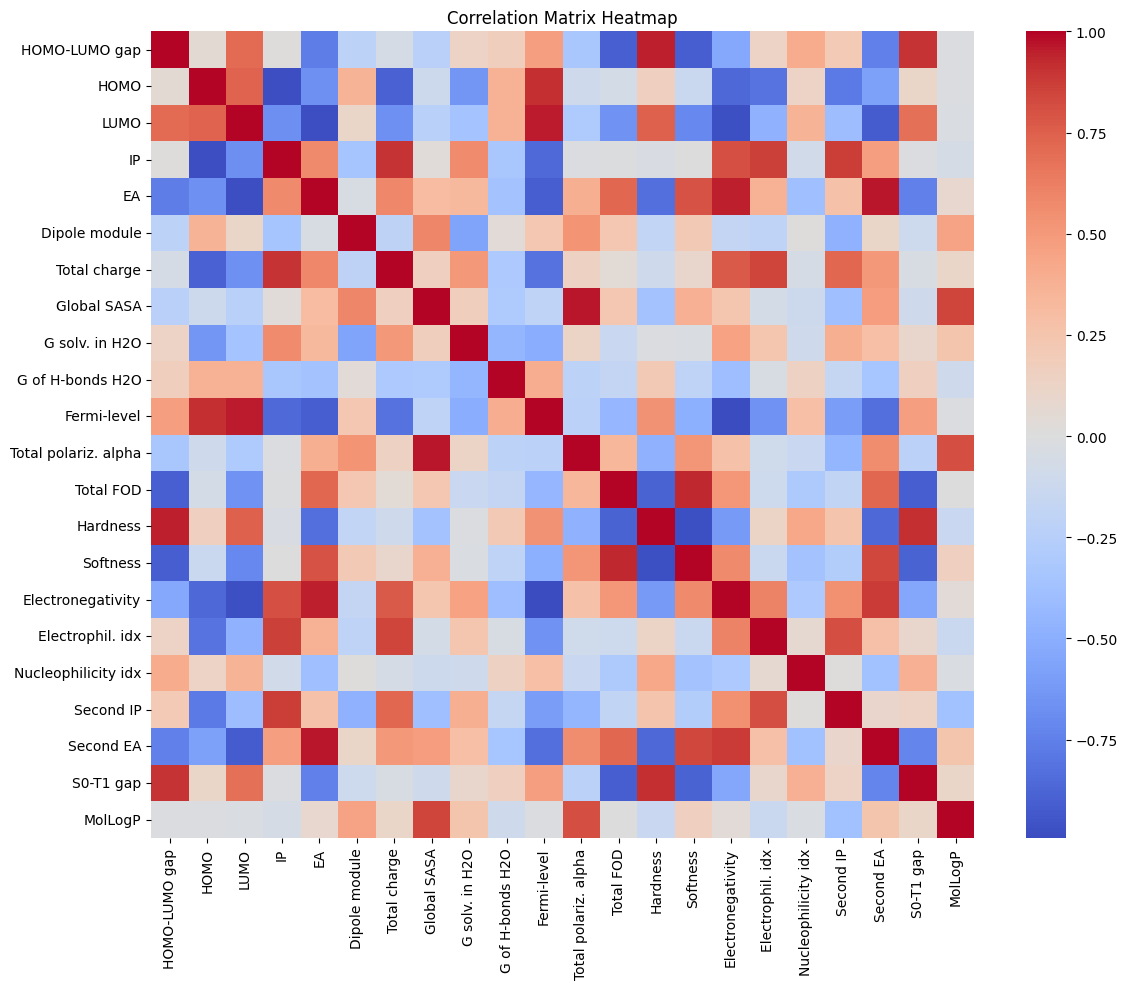

In [21]:
# Calculate the correlation matrix
correlation_matrix = df_numeric.corr()

# Now we can do the collinearity check. We will use the correlation matrix to identify any pairs of features that are highly correlated with each other. We will then drop one of the features from each pair of highly correlated features.
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()

In [22]:
# remove features which are highly correlated

cutoff = 0.9

print(f"Original number of features: {df_numeric.shape[1]}")
df_corr = df_numeric.corr()
df_not_correlated = ~(df_corr.mask(np.tril(np.ones([len(df_corr)]*2, dtype=bool))).abs() > cutoff).any()
un_corr_index = df_not_correlated.loc[df_not_correlated[df_not_correlated.index] == True].index
sel_features_df = df_numeric[un_corr_index]
print(f"Reduced number of features: {sel_features_df.shape[1]}")

Original number of features: 22
Reduced number of features: 11


In [23]:
# Lets look at the remaining features.
sel_features_df.head()

,HOMO-LUMO gap,HOMO,LUMO,Dipole module,Global SASA,G solv. in H2O,G of H-bonds H2O,Electrophil. idx,Nucleophilicity idx,Second IP,MolLogP
code_name,,,,,,,,,,,
Anion_0001,5.3351,-4.2024,1.1327,7.1380,192.5967,-68.9658,-2.1547,0.4616,4166.6667,11.1108,-1.2438
Anion_0002,4.0571,-10.3812,-6.3242,1.8413,600.8035,-9.6848,-5.2430,0.5261,1.5797,10.8525,6.1085
Anion_0003,5.3131,-4.3573,0.9559,37.5426,598.9517,-70.5050,-2.3100,0.3239,1843.3891,7.9764,4.2176
Anion_0004,5.2403,-4.5644,0.6759,27.8235,610.9026,-69.4885,-1.8624,0.3234,1522.5735,7.7882,4.9978
Anion_0005,4.0262,-10.3534,-6.3272,1.8364,568.8514,-10.4796,-5.9490,0.5978,1.4856,11.0191,5.4944


Note that there is no chemical basis for removing one feature over another, they are removed based on the order they get to in the spreadsheet. Alternative approaches might be to keep the ones which are chemically meaningful to a given reaction (and then do a collinearlity removal depending on what's left).

*Based on the amide coupling reaction, which features might be the most interpretable ones to keep?*

Now we have removed the features which are collinear, we need to make sure they are all on the same scale. Don't worry too much about what this means now, we will cover this in Lecture 4.

In [24]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the selected features
sel_features_df_scaled = scaler.fit_transform(sel_features_df)

# Convert back to DataFrame to preserve column names and index
sel_features_df_scaled = pd.DataFrame(sel_features_df_scaled, columns=sel_features_df.columns, index=sel_features_df.index)

sel_features_df_scaled.head()

# finally save the scaled features to a new csv file (you'll need this for Exercise 1)
sel_features_df_scaled.to_csv("scaled_features.csv")

Finally, we are ready to run the PCA. First we need to define the number of components we want to have. Let's say 4 to start with.

In [25]:
pca = PCA(n_components=4)
pca_reduced = pca.fit(sel_features_df_scaled)

We can look at the PCA components and the explained variance for each component:

In [ ]:
# PCA components
print(pca_reduced.components_)

# Explained variance ratio
print(pca_reduced.explained_variance_ratio_ * 100)

[[ 0.03044259  0.49118284  0.3661133   0.29062865  0.06459299 -0.34260943
   0.20468772 -0.39882868  0.08466282 -0.44595389  0.10368788]
 [-0.35014092 -0.10899848 -0.3121815   0.3189607   0.54036233  0.11677991
  -0.26352501 -0.06552511 -0.22743915 -0.20742737  0.43841167]
 [ 0.57603464 -0.10038168  0.31676597  0.01641291  0.27787927  0.31811611
  -0.07021919  0.11282497  0.41624115  0.04164419  0.43177734]
 [-0.03516866 -0.13740426 -0.12034061  0.47348187  0.10620339 -0.47508123
   0.36704171  0.5135465   0.25472327  0.2003555   0.02755103]]
[34.02744162 24.88588004 14.87882419 11.04425611]


Finally, we can extract the individual principal components and plot the result.

In [34]:
sel_features_df["PC1"] = pca_reduced.transform(sel_features_df_scaled)[:, 0]
sel_features_df["PC2"] = pca_reduced.transform(sel_features_df_scaled)[:, 1]
sel_features_df["PC3"] = pca_reduced.transform(sel_features_df_scaled)[:, 2]
sel_features_df["PC4"] = pca_reduced.transform(sel_features_df_scaled)[:, 3]

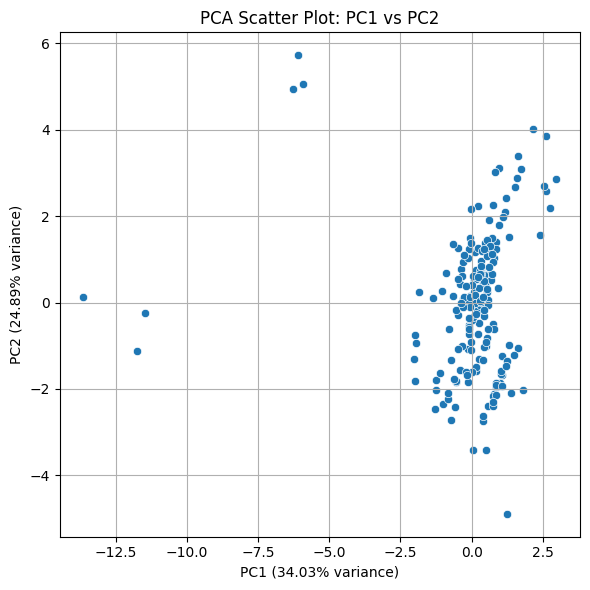

In [36]:
dim1 = "PC1"
dim2 = "PC2"

plt.figure(figsize=(6,6))
sns.scatterplot(data=sel_features_df, x=dim1, y=dim2)
plt.title(f"PCA Scatter Plot: {dim1} vs {dim2}")
plt.xlabel(f"{dim1} ({pca_reduced.explained_variance_ratio_[0] * 100:.2f}% variance)")
plt.ylabel(f"{dim2} ({pca_reduced.explained_variance_ratio_[1] * 100:.2f}% variance)")
plt.grid()
plt.tight_layout()
plt.show()

*Sometimes it is useful to color these plots using the features - see if you can work out how to do that*

To finish off, let's export the PCA coordinates to a CSV file to use later.

In [37]:
sel_features_df.to_csv("pca_reduced_features.csv")